In [4]:
import numpy as np
import matplotlib.pyplot as plt

# GENERAL PLOT OPTIONS
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
matplotlib.rcParams['mathtext.rm'] = 'Bitstream Vera Sans'
matplotlib.rcParams['mathtext.it'] = 'Bitstream Vera Sans:italic'
matplotlib.rcParams['mathtext.bf'] = 'Bitstream Vera Sans:bold'
matplotlib.rcParams['xtick.bottom'] = True
matplotlib.rcParams['xtick.top'] = False
matplotlib.rcParams['ytick.right'] = False
matplotlib.rcParams['axes.edgecolor'] = 'black'
matplotlib.rcParams['axes.linewidth'] = '1.3'
matplotlib.rcParams['axes.labelsize'] = 'large'
matplotlib.rcParams['axes.labelweight'] = 'bold'
matplotlib.rcParams['axes.grid'] = True
matplotlib.rcParams['grid.linewidth'] = '1.0'
matplotlib.rcParams['grid.alpha'] = '0.3'
matplotlib.rcParams['grid.color'] = 'lightgray'
matplotlib.rcParams['legend.labelspacing'] = 0.77
matplotlib.rcParams['savefig.bbox'] = 'tight'
matplotlib.rcParams['savefig.format'] = 'pdf'
matplotlib.rcParams['figure.dpi'] = 400          # 提高渲染清晰度
matplotlib.rcParams['savefig.dpi'] = 400
matplotlib.rcParams['figure.facecolor'] = 'white'
matplotlib.rcParams['font.weight'] = 'bold' 
matplotlib.rcParams['font.size'] = 18 

### n(z) for Lsst

lens galaxy density are:  [1.80508666 2.55461328 3.09124442 3.40807413 3.53410391 3.51006927
 3.37682586 3.17027038 2.91963646 2.64746576]
srcs galaxy density are:  [5.42 5.42 5.42 5.42 5.42]


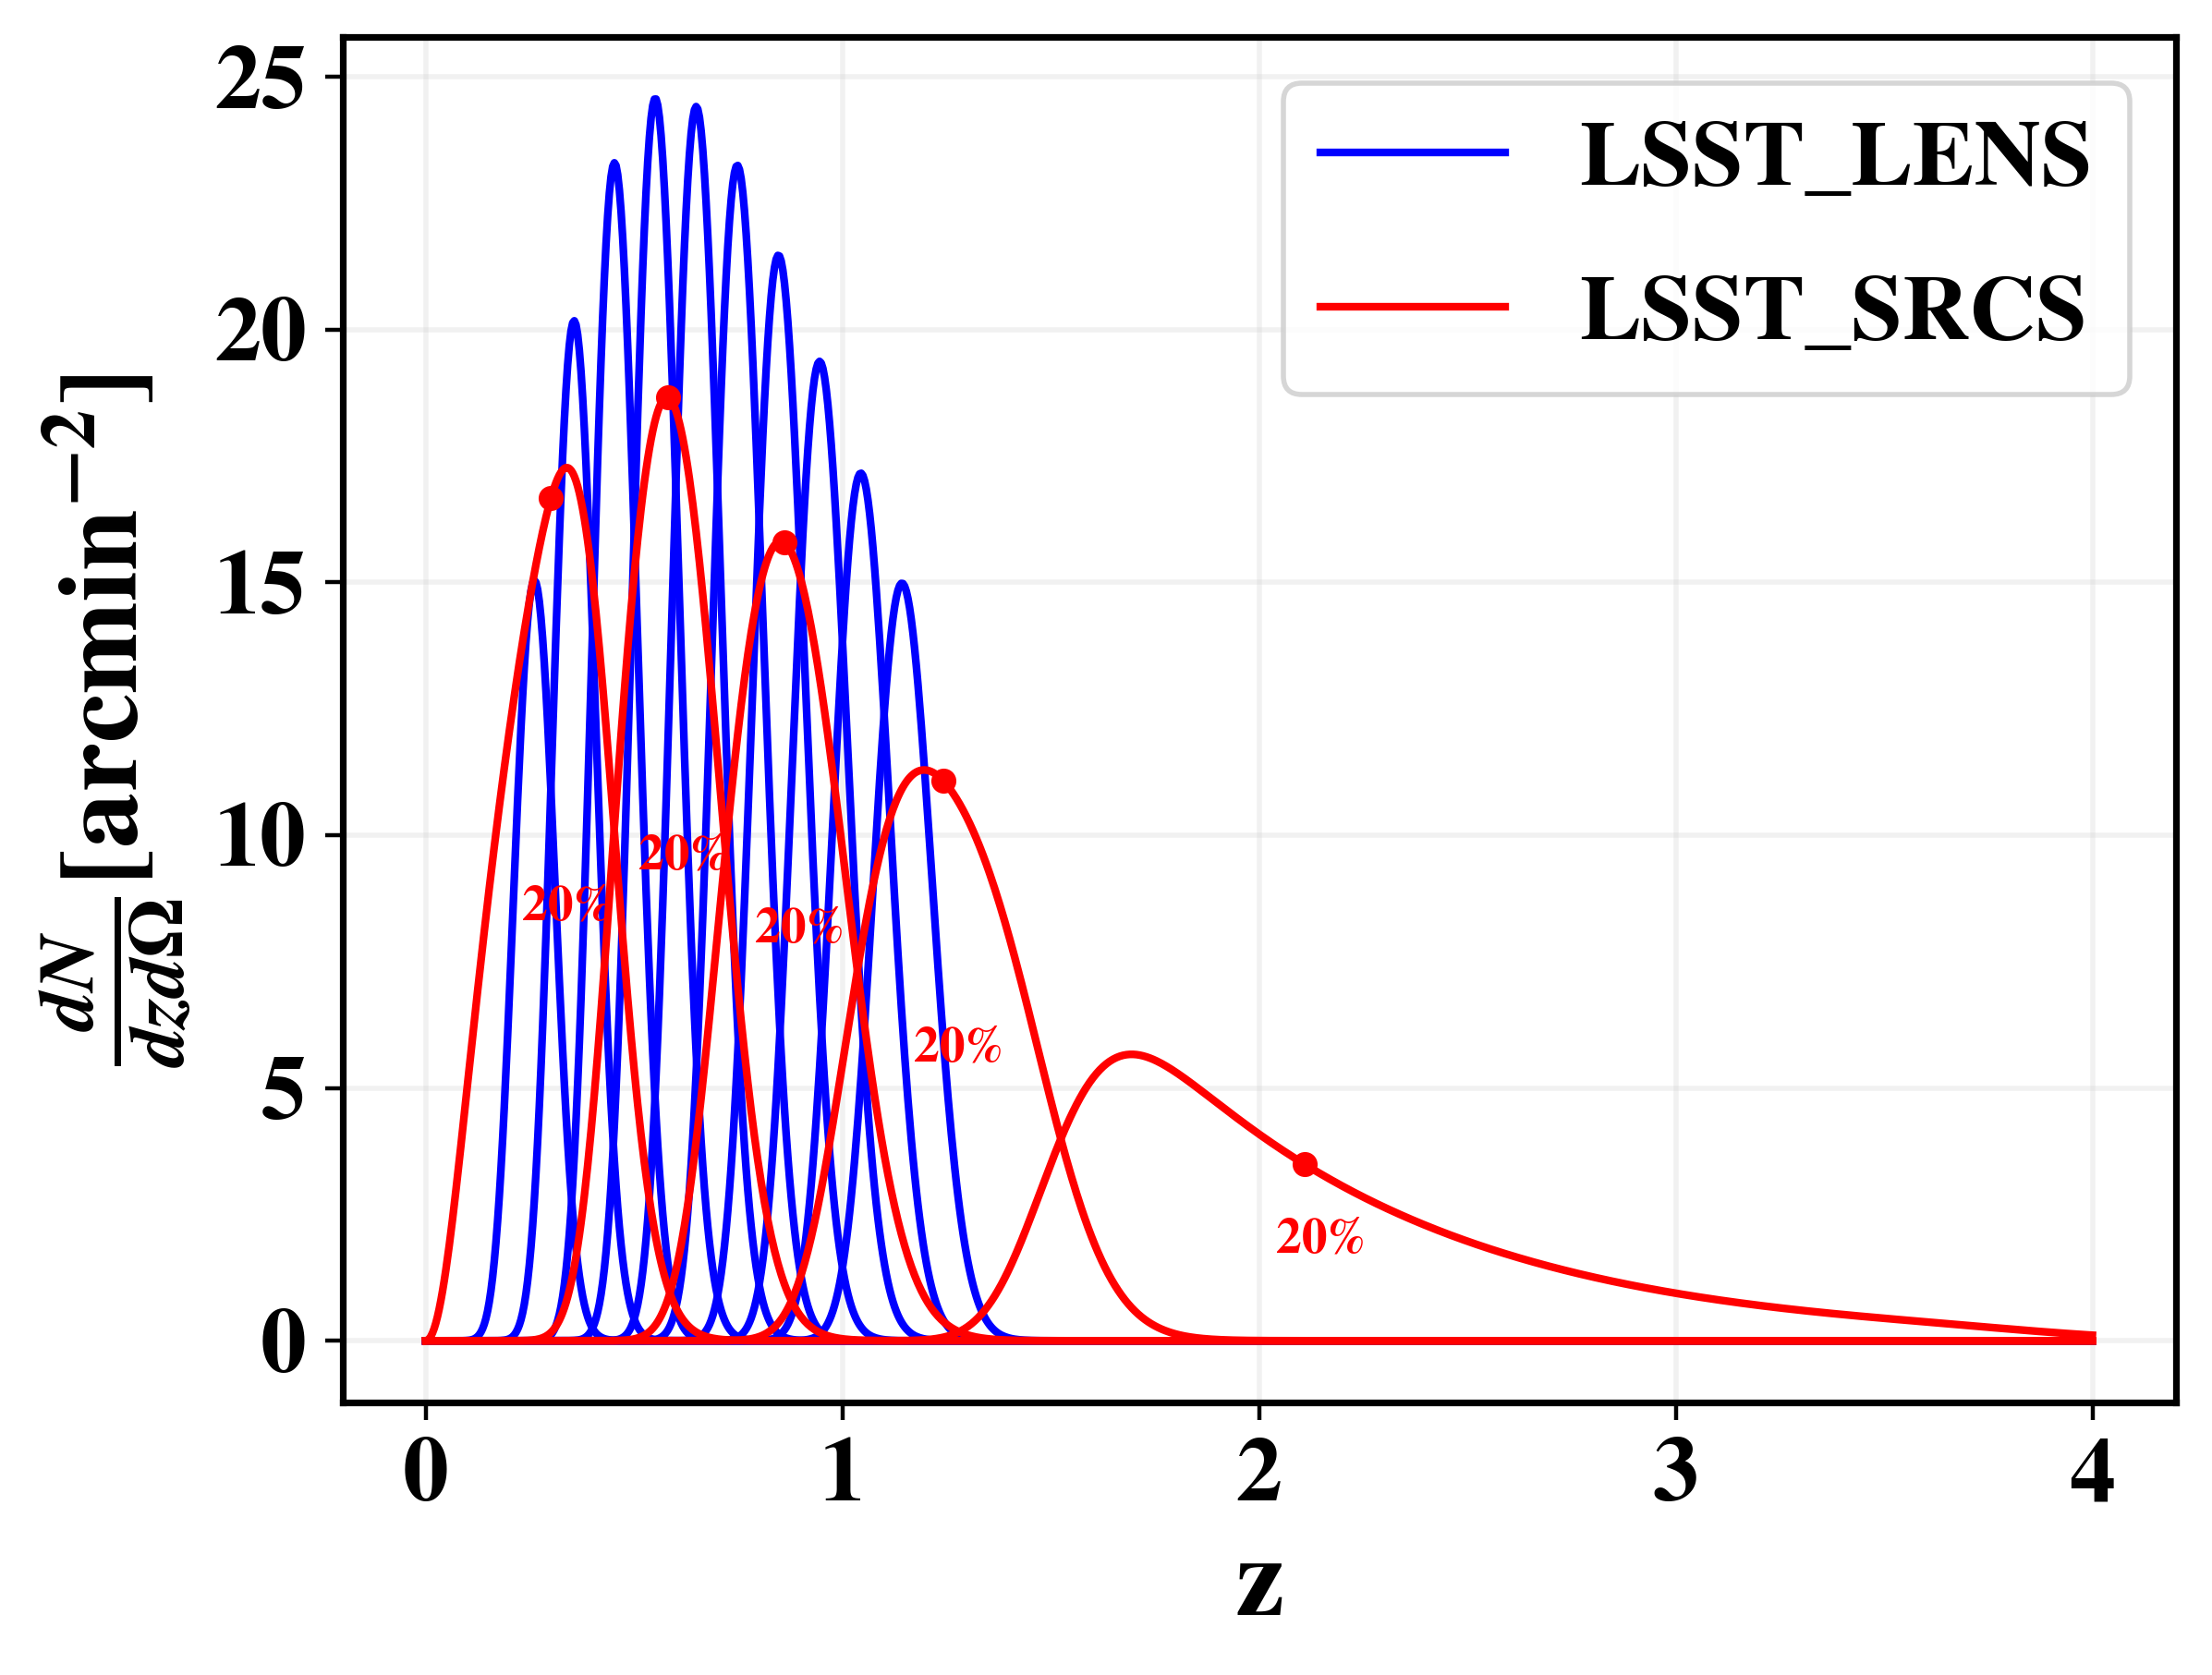

Text(0, 0.5, '$\\frac{dN}{dzd\\Omega}[\\mathrm{arcmin}^{-2}]$')

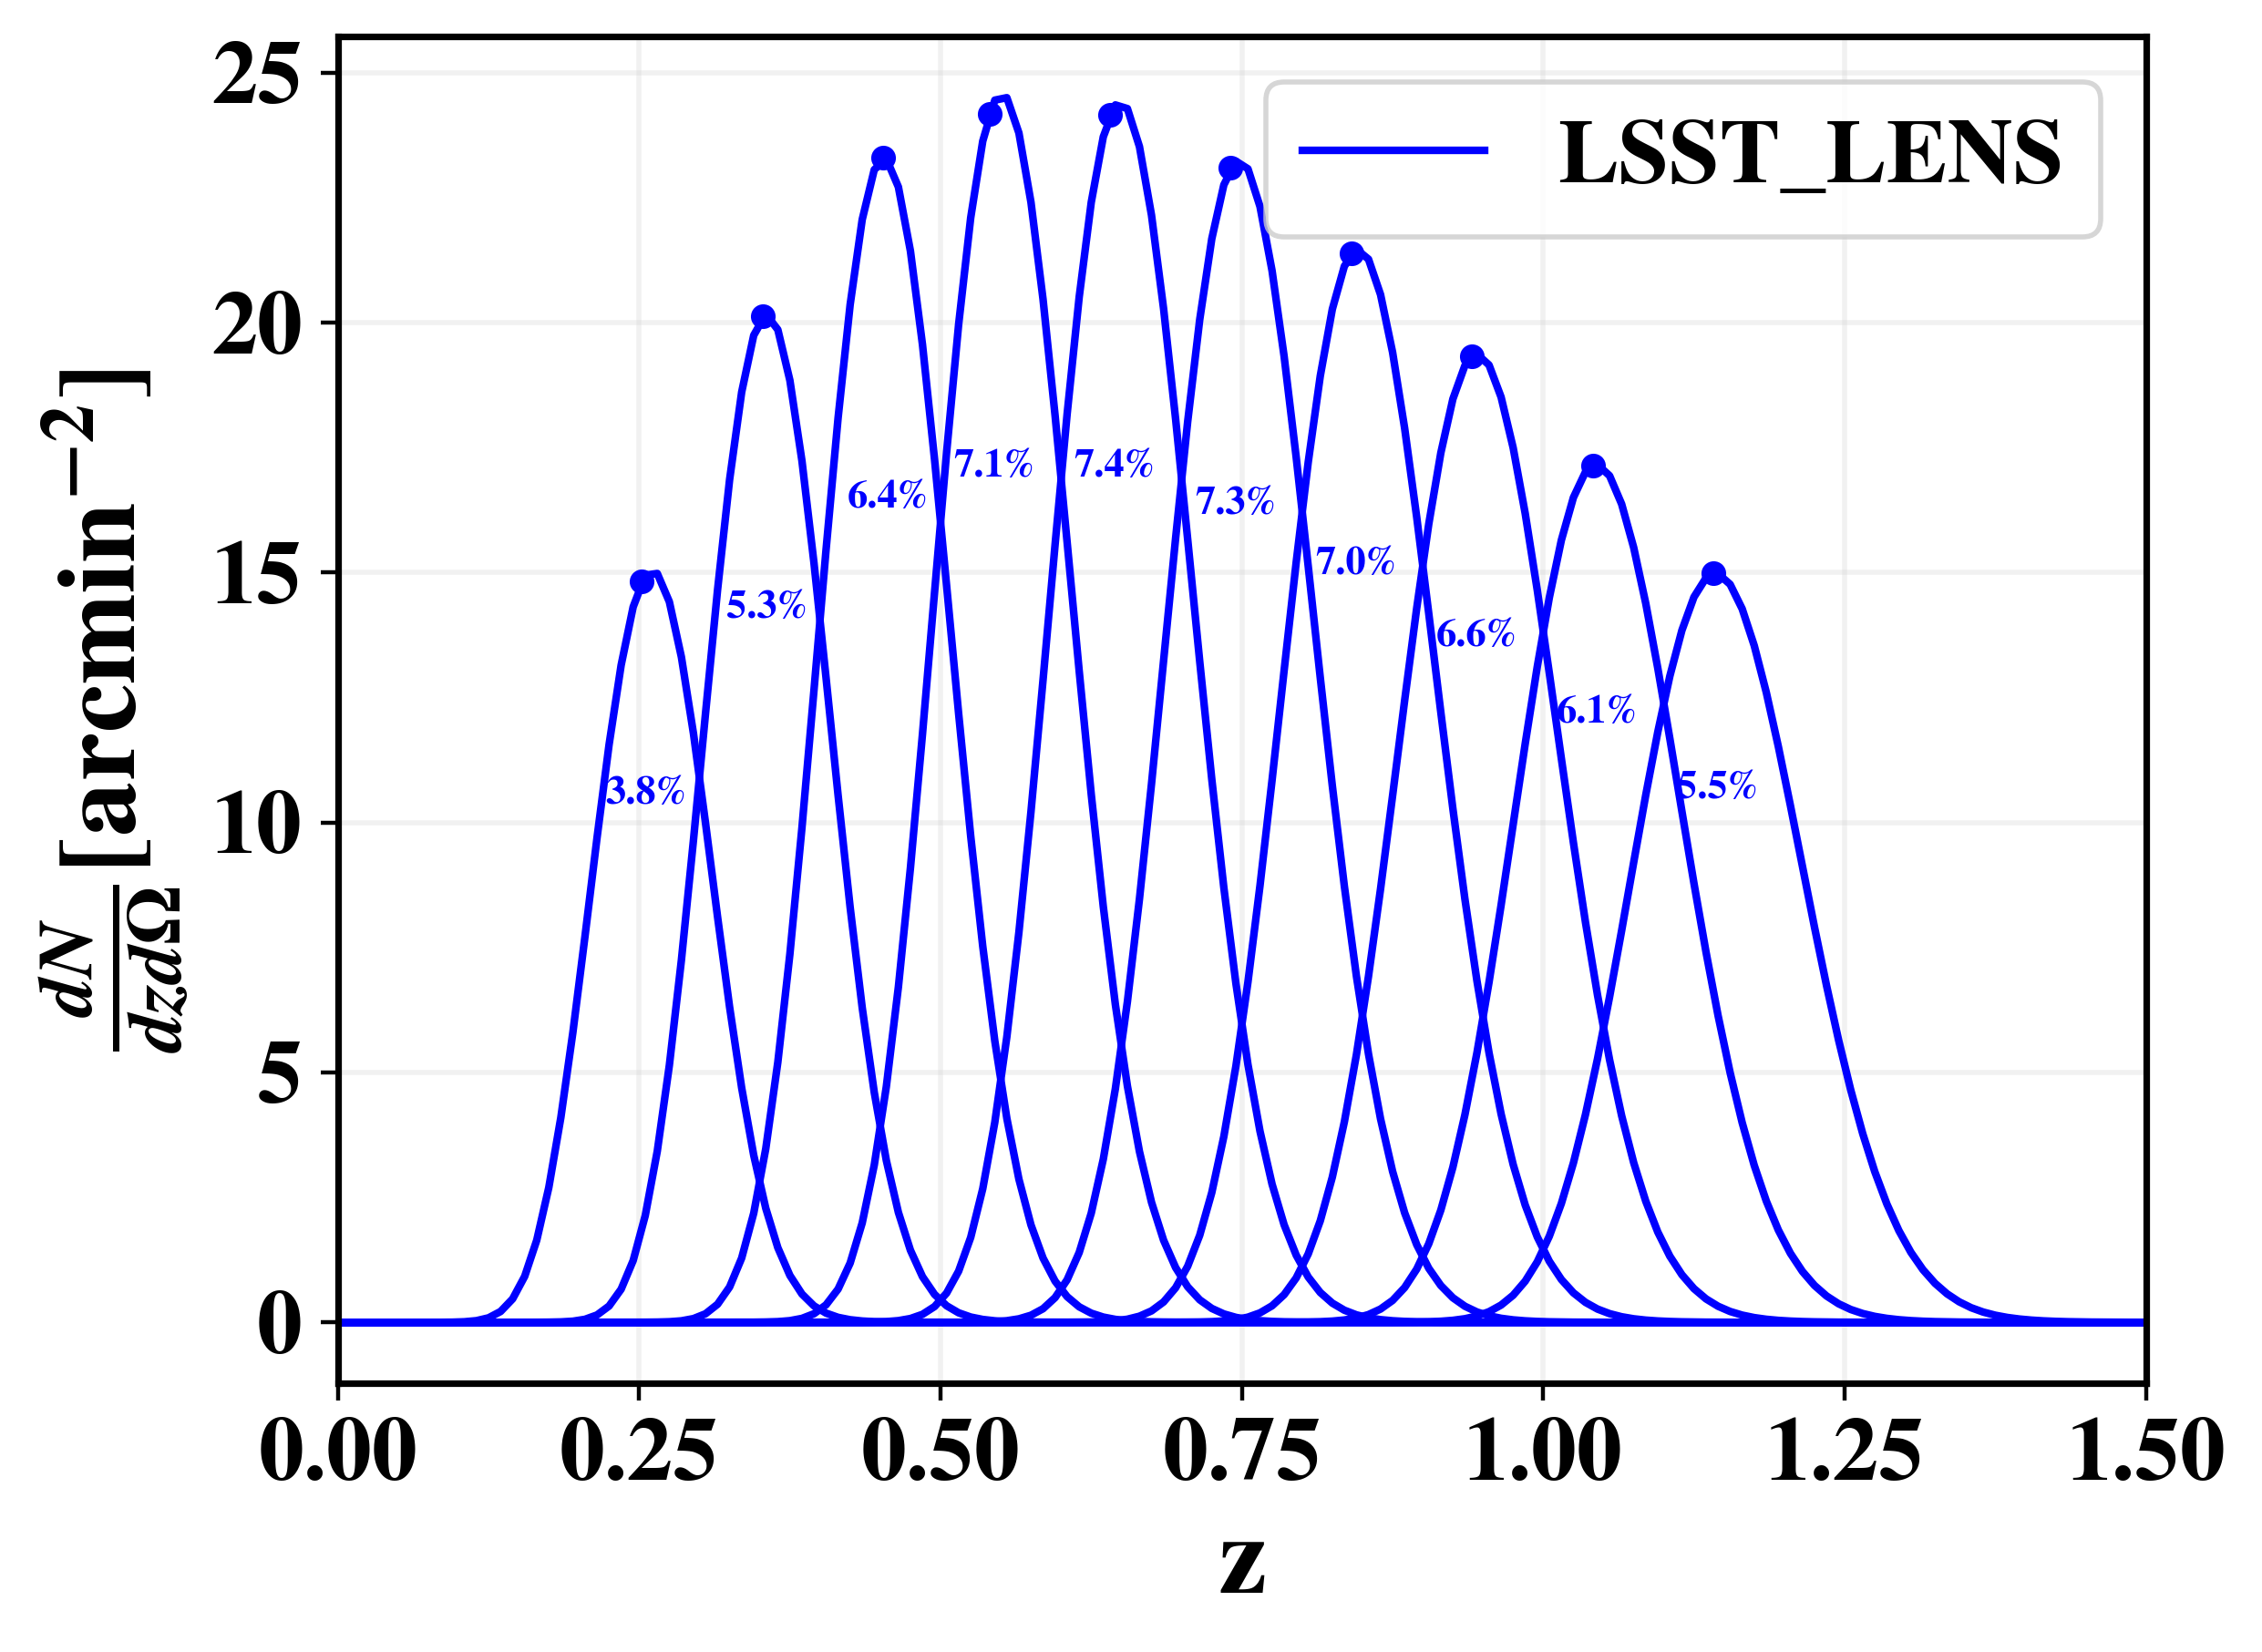

In [45]:
from scipy.interpolate import interp1d

lsst_lens = np.loadtxt('/project/chihway/junzhou/cocoa_approx/Cocoa/projects/lsst_real/data/lsst_lens_4firecrown.nz')
lsst_srcs =np.loadtxt('/project/chihway/junzhou/cocoa_approx/Cocoa/projects/lsst_real/data/lsst_srcs_4firecrown.nz')

lens_centers = [0.26, 0.36, 0.46, 0.55, 0.65, 0.75, 0.85, 0.95, 1.05, 1.15]
srcs_centers = [0.31, 0.59, 0.87, 1.25, 2.12]
lens_prob_mass = [0.037605972071246344, 0.05322110990726346, 0.06440092535187608, 
0.0710015443371609, 0.07362716482381701, 0.07312644303475142, 0.07035053881560904, 0.06604729962819815, 0.060825759540392856, 0.05515553661227458]
lens_ngal = np.array(lens_prob_mass)*48
print('lens galaxy density are: ', lens_ngal)
srcs_prob_mass = [0.2, 0.2, 0.2, 0.2, 0.2]
srcs_ngal = np.array(srcs_prob_mass)*27.1
print('srcs galaxy density are: ', srcs_ngal)

f_lens = []
f_srcs = []
for i in range(10):
    f_lens.append(interp1d(lsst_lens[:,0], lsst_lens[:,i+1]*48, kind='cubic', fill_value='extrapolate'))
for i in range(5):
    f_srcs.append(interp1d(lsst_srcs[:,0], lsst_srcs[:,i+1]*27.1, kind='cubic', fill_value='extrapolate'))
z_interp = np.linspace(0,4,1000)
plt.plot(z_interp, f_lens[0](z_interp),'b',label='LSST_LENS')
plt.plot(z_interp, np.array([f(z_interp) for f in f_lens[1:]]).T,'b')
plt.plot(z_interp, f_srcs[0](z_interp), 'r', label='LSST_SRCS')
plt.plot(z_interp, np.array([f(z_interp) for f in f_srcs[1:]]).T,'r')
plt.legend()
plt.xlabel('z')
plt.ylabel(r'$\frac{dN}{dzd\Omega}[\mathrm{arcmin}^{-2}]$')
for i in range(5):
    arg = np.argwhere(np.abs(z_interp-srcs_centers[i])<0.01)[0][0]
    plt.scatter(z_interp[arg], f_srcs[i](z_interp[arg]),color='r',marker='o',s=15,alpha=1.0,zorder=10)
    plt.text(z_interp[arg]-0.07, f_srcs[i](z_interp[arg])*0.5,s=f'20%', color='r', size=10)
plt.show()

plt.plot(lsst_lens[:,0], lsst_lens[:,1]*48,'b',label='LSST_LENS')
plt.plot(lsst_lens[:,0], lsst_lens[:,2:]*48,'b')
for i in range(10):
    arg = np.argwhere(np.abs(z_interp-lens_centers[i])<0.01)[0][0]
    plt.scatter(z_interp[arg], f_lens[i](z_interp[arg]),color='b',marker='o',s=15,alpha=1.0,zorder=10)
    plt.text(z_interp[arg]-0.03, f_lens[i](z_interp[arg])*0.7, s=f'{lens_prob_mass[i]*100:.1f}%', color='b',size=8)
plt.xlim(0,1.5)
plt.legend()
plt.xlabel('z')
plt.ylabel(r'$\frac{dN}{dzd\Omega}[\mathrm{arcmin}^{-2}]$')

### Roman Sourcs x LSST Lens

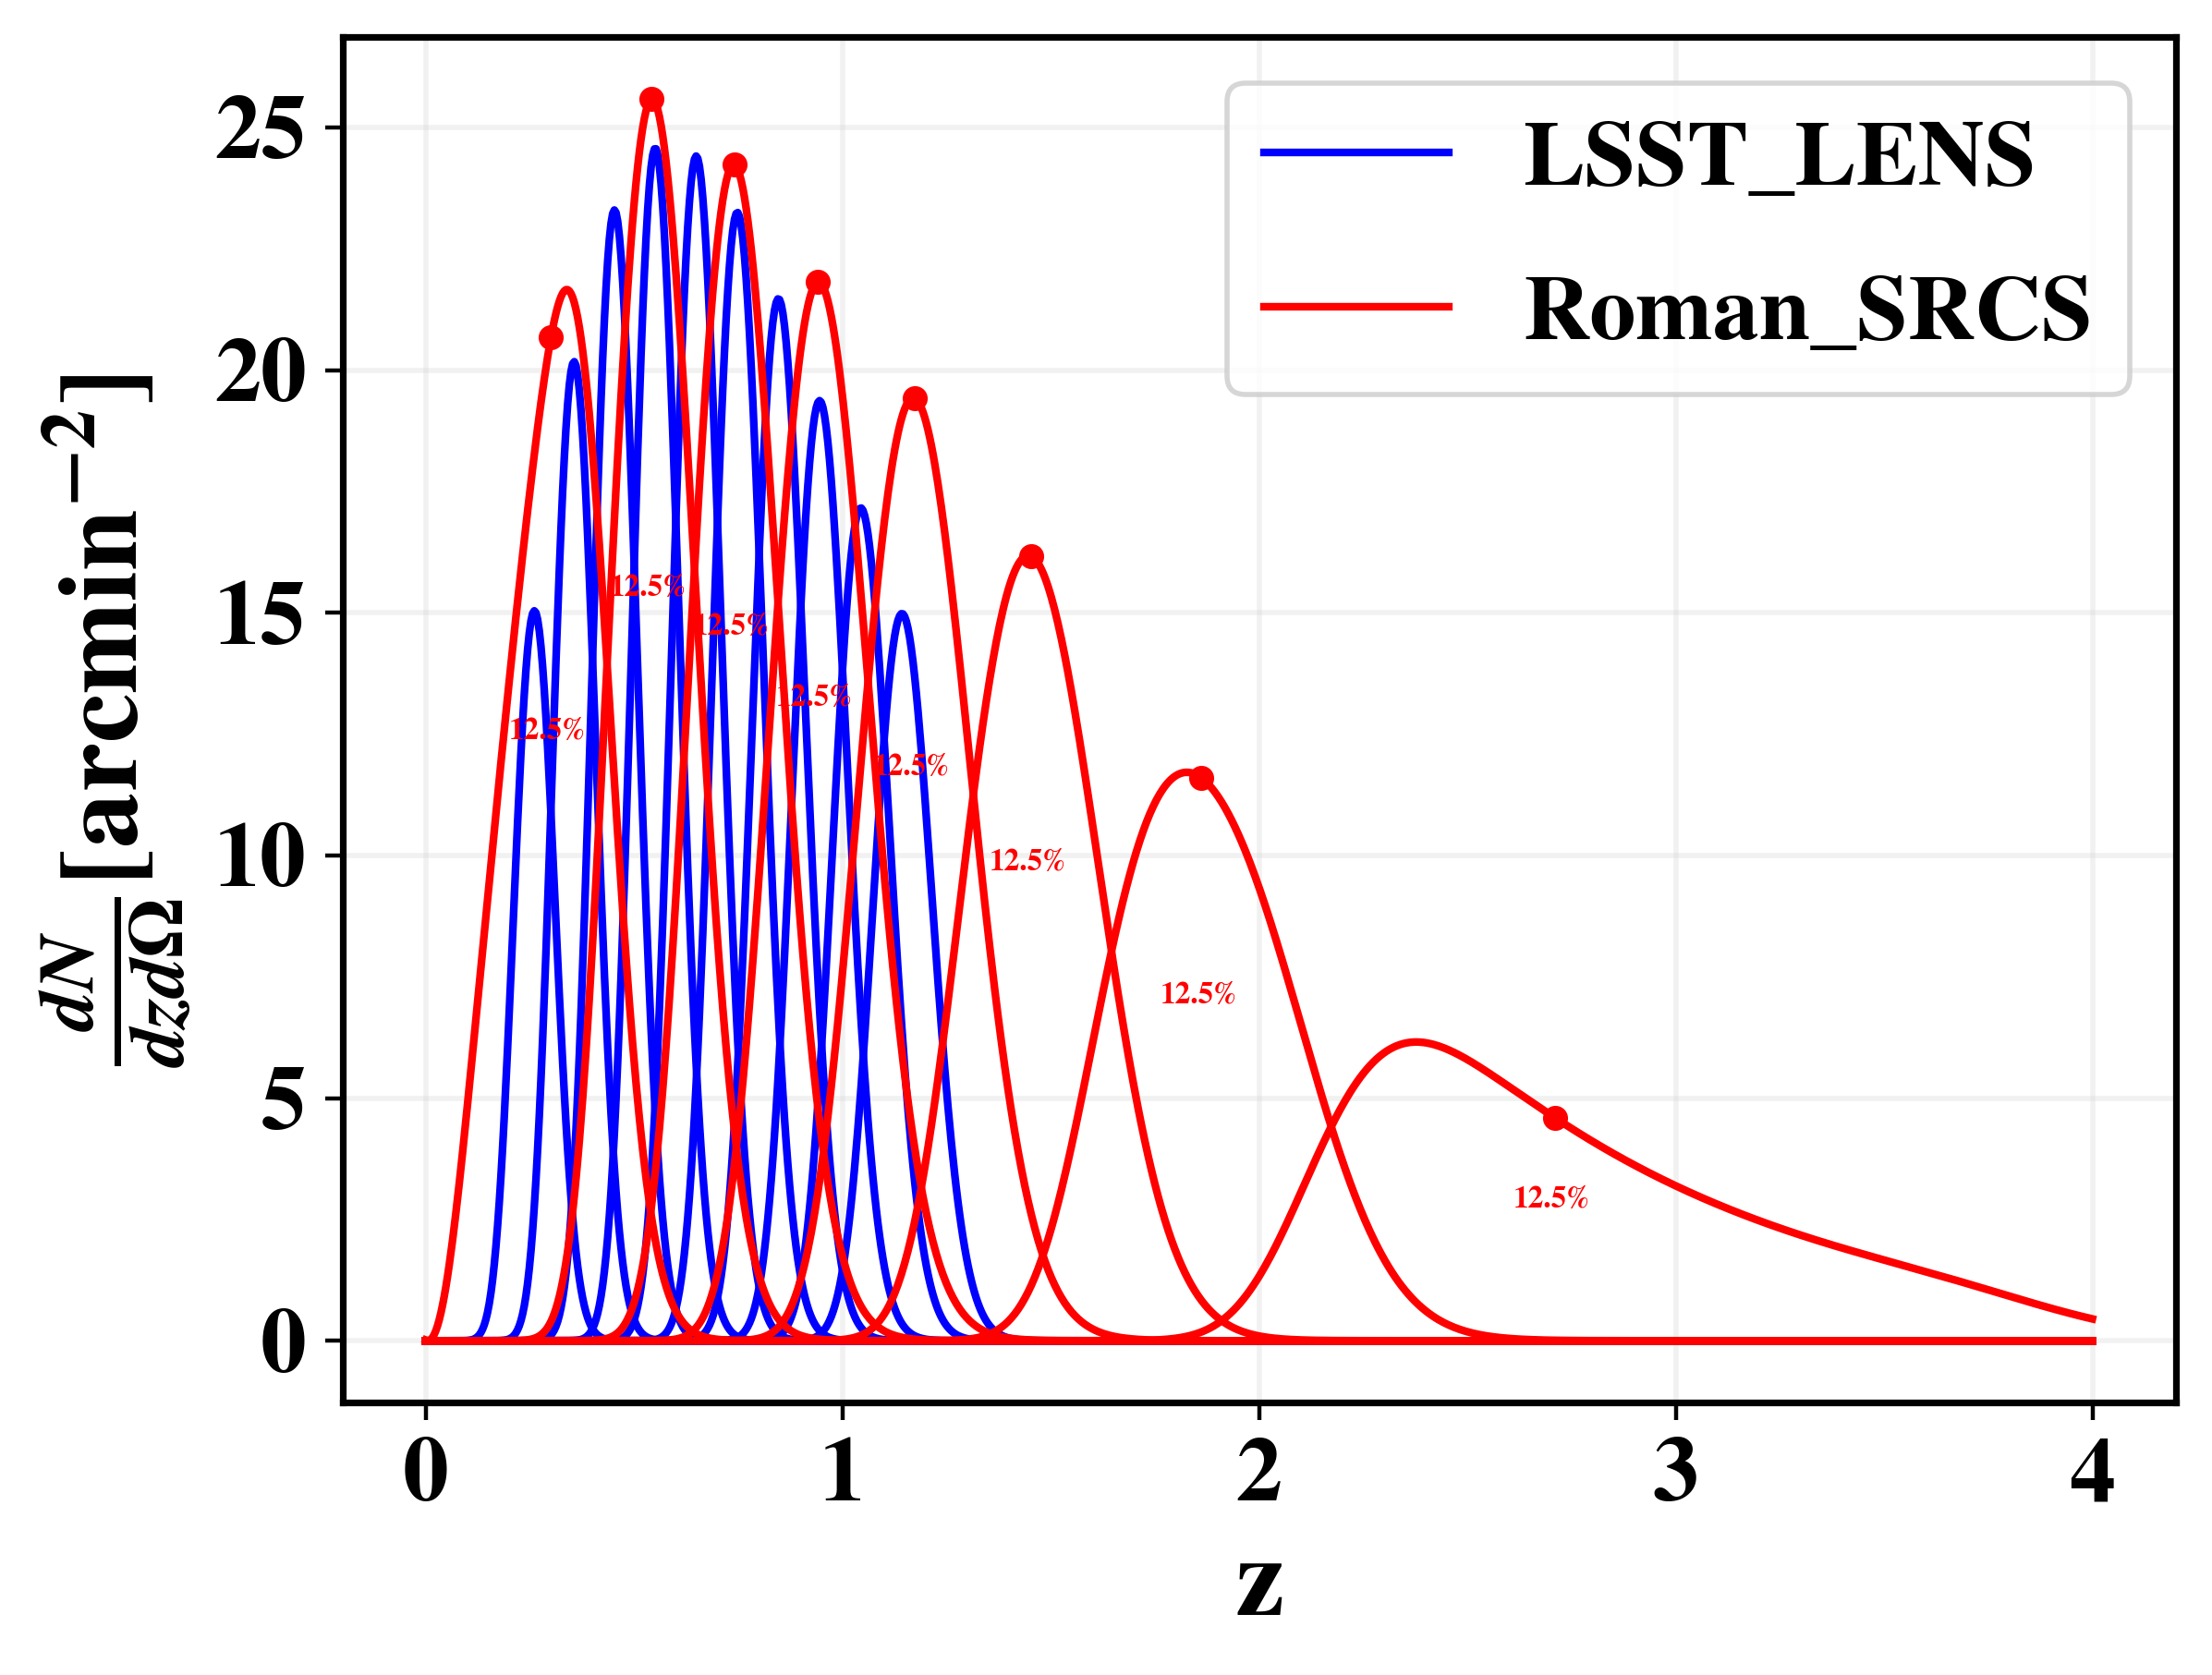

In [44]:
from scipy.interpolate import interp1d

lsst_lens = np.loadtxt('/project/chihway/junzhou/cocoa_approx/Cocoa/projects/lsst_real/data/lsst_lens_4firecrown.nz')
roman_srcs =np.loadtxt('/project/chihway/junzhou/cocoa_approx/Cocoa/projects/roman_real/data/fiducial.nz')

srcs_centers = []
for i in range(8):
    weighted_sum = np.trapz(roman_srcs[:,i+1]*roman_srcs[:,0], roman_srcs[:,0])
    total_area = np.trapz(roman_srcs[:,i+1], roman_srcs[:,0])

    # Calculate weighted mean redshift (bin center)
    weighted_mean = weighted_sum / total_area

    # Round the result to the specified number of decimal places
    srcs_centers.append(np.round(weighted_mean,2))

f_lens = []
f_srcs = []
for i in range(10):
    f_lens.append(interp1d(lsst_lens[:,0], lsst_lens[:,i+1]*48, kind='cubic', fill_value='extrapolate'))
for i in range(8):
    f_srcs.append(interp1d(roman_srcs[:,0]+0.005, roman_srcs[:,i+1]*51, kind='cubic', fill_value='extrapolate'))
z_interp = np.linspace(0,4,1000)
plt.plot(z_interp, f_lens[0](z_interp),'b',label='LSST_LENS')
plt.plot(z_interp, np.array([f(z_interp) for f in f_lens[1:]]).T,'b')
plt.plot(z_interp, f_srcs[0](z_interp), 'r', label='Roman_SRCS')
plt.plot(z_interp, np.array([f(z_interp) for f in f_srcs[1:]]).T,'r')
plt.legend()
plt.xlabel('z')
plt.ylabel(r'$\frac{dN}{dzd\Omega}[\mathrm{arcmin}^{-2}]$')
for i in range(8):
    arg = np.argwhere(np.abs(z_interp-srcs_centers[i])<0.01)[0][0]
    plt.scatter(z_interp[arg], f_srcs[i](z_interp[arg]),color='r',marker='o',s=15,alpha=1.0,zorder=10)
    plt.text(z_interp[arg]-0.10, f_srcs[i](z_interp[arg])*0.6,s=f'12.5%', color='r', size=6)
plt.show()


#### previous pipeline

In [41]:
sum_roman = 0
for i in range(8):
    sum_roman += np.sum(nz_roman[:,i+1]*0.01)
    print(f'sum_roman_{i}',np.sum(nz_roman[:,i+1]*0.01))
print('sum_roman = ', sum_roman)

sum_lsst = 0
for i in range(10):
    sum_lsst += np.sum(nz_lsst[:,i+1]*0.01)
    print(f'sum_lsst_{i}',np.sum(nz_lsst[:,i+1]*0.01))
print('sum_lsst = ', sum_lsst)

sum_roman_0 0.125
sum_roman_1 0.12500000000000003
sum_roman_2 0.12499999999999999
sum_roman_3 0.125
sum_roman_4 0.12500000000000003
sum_roman_5 0.125
sum_roman_6 0.12500000000000003
sum_roman_7 0.12504508012474488
sum_roman =  1.000045080124745
sum_lsst_0 0.1
sum_lsst_1 0.09999999999999999
sum_lsst_2 0.10000000000000002
sum_lsst_3 0.09999999999999999
sum_lsst_4 0.09999999999999999
sum_lsst_5 0.1
sum_lsst_6 0.09999999999999999
sum_lsst_7 0.1
sum_lsst_8 0.10000000000000002
sum_lsst_9 0.1000217179605319
sum_lsst =  1.0000217179605317


Text(0, 0.5, '$\\frac{dN}{dzd\\Omega}[\\mathrm{arcmin}^{-2}]$')

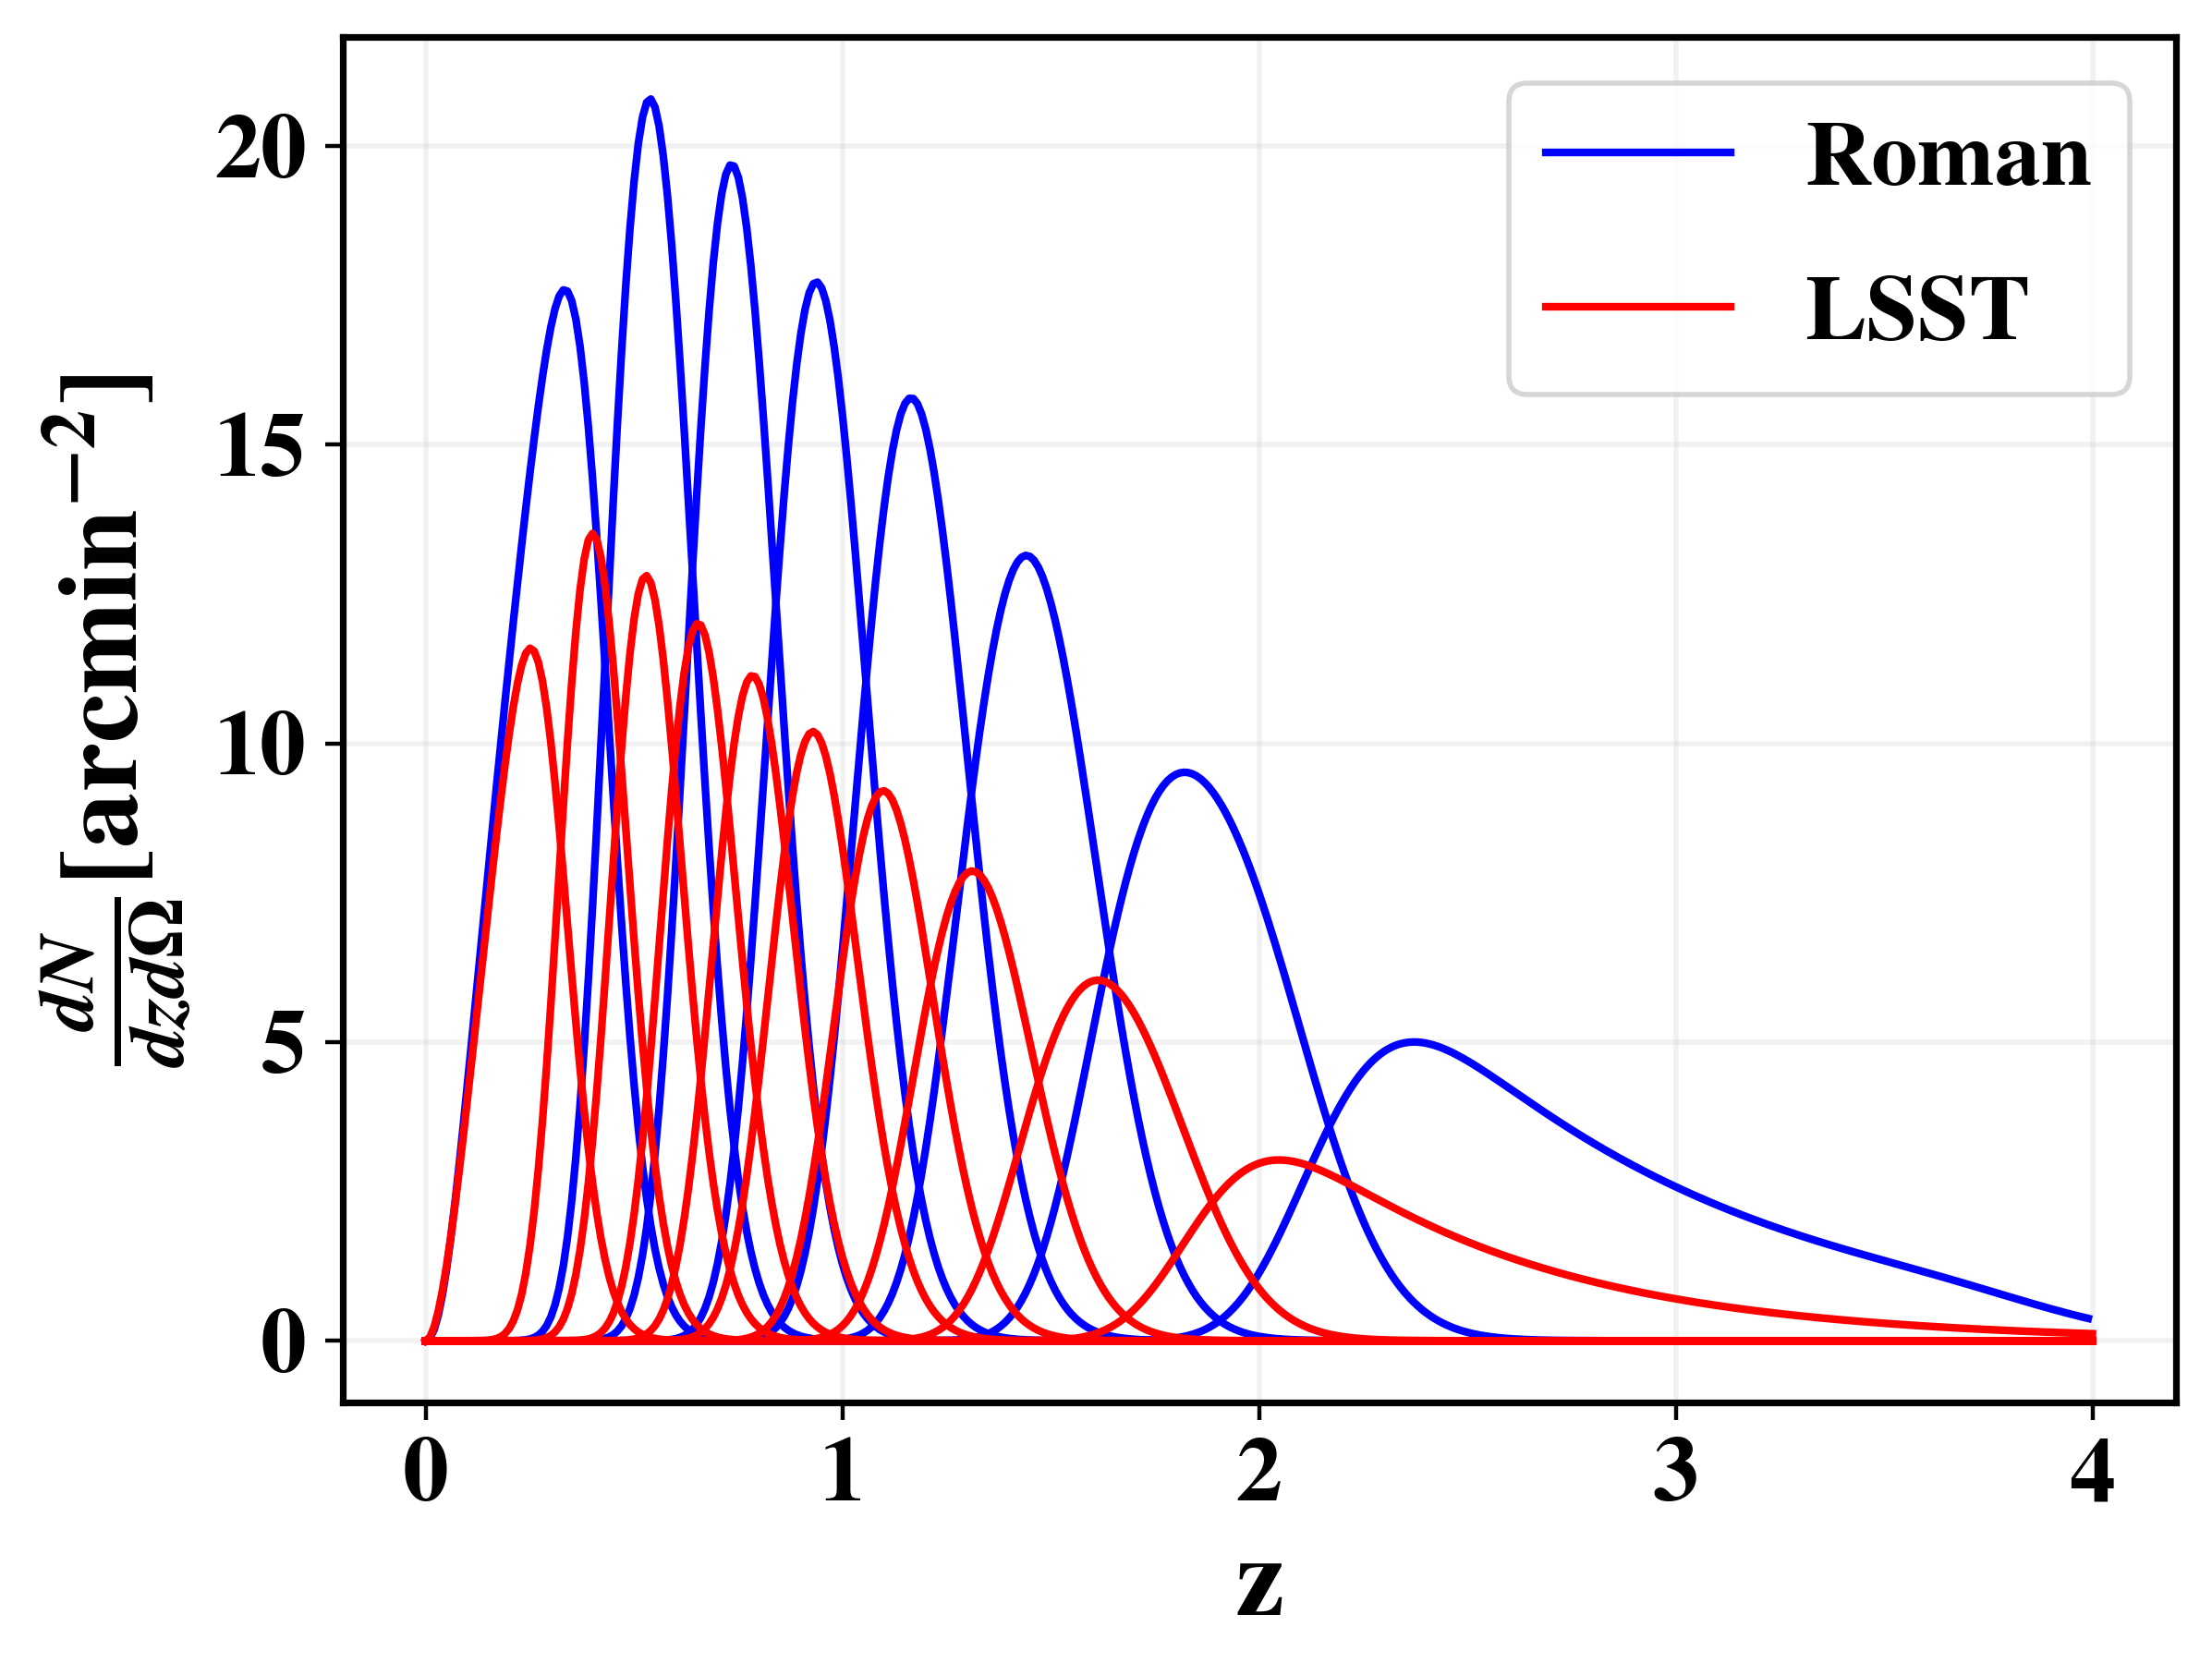

In [42]:
plt.plot(nz_roman[:,0], nz_roman[:,1]*8*5.18,'b',label='Roman')
plt.plot(nz_roman[:,0], nz_roman[:,2:]*8*5.18,'b')
plt.plot(nz_lsst[:,0], nz_lsst[:,1]*10*2.71,'r',label='LSST')
plt.plot(nz_lsst[:,0], nz_lsst[:,2:]*10*2.71,'r')
plt.legend()
plt.xlabel('z')
plt.ylabel(r'$\frac{dN}{dzd\Omega}[\mathrm{arcmin}^{-2}]$')